# Импорт пакетов

In [58]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme()

# Загрузка данных

In [59]:
employeeRaw = (pd
                .read_excel("empl_1.xlsx")
                .sort_values('date')
)
dataRaw = (pd
           .read_excel("data_1.xlsx")
           .sort_values('date')
)
print("Сотрудники: ", employeeRaw.shape)
print("Покупки: ", dataRaw.shape)

print(dataRaw.groupby("category").nunique().index.tolist())

Сотрудники:  (129, 3)
Покупки:  (4728, 5)
['Батарейка', 'Блок питания', 'Веб-камера', 'Видеокарта', 'Жесткий диск', 'Запчасти для компьютера', 'Запчасти для принтера', 'Кабель/Адаптер', 'Картридж', 'Клавиатура', 'Коммутатор/Свитч/Роутер', 'Компьютер/Ноутбук', 'Корпус компьютерный', 'МФУ', 'Материнская плата', 'Монитор', 'Мышь', 'Наушники', 'ОЗУ', 'Принтер', 'Программное обеспечение', 'Процессор', 'Прочее', 'Сетевое оборудование', 'Смартфон/Мобильное устройство', 'Телевизор', 'Тонер/Чернила', 'Флеш накопитель']


# Подготавливаем данные

In [60]:
## Сотрудники
employee = (
    employeeRaw
    .assign(delta = lambda x: x["qty"] - x["qty"].shift(1))
    .assign(year = lambda x: x["date"].dt.year)
    .assign(month = lambda x: x["date"].dt.month)
    .assign(quarter = lambda x: x["date"].dt.quarter)
    .fillna(0)
)

print(employee)

          date  total_qty  qty  delta  year  month  quarter
0   2016-01-01        842  484    0.0  2016      1        1
1   2016-02-01        840  483   -1.0  2016      2        1
2   2016-03-01        841  487    4.0  2016      3        1
3   2016-04-01        841  489    2.0  2016      4        2
4   2016-05-01        838  489    0.0  2016      5        2
..         ...        ...  ...    ...   ...    ...      ...
124 2026-05-01        997  577    5.0  2026      5        2
125 2026-06-01        997  576   -1.0  2026      6        2
126 2026-07-01        998  578    2.0  2026      7        3
127 2026-08-01        996  577   -1.0  2026      8        3
128 2026-09-01        996  577    0.0  2026      9        3

[129 rows x 7 columns]


In [72]:
## Покупки
dataMonitor = (
    #dataRaw[dataRaw["category"] == "Монитор"]
    #dataRaw[dataRaw["category"] == "Картридж"]
    dataRaw[dataRaw["category"] == "Компьютер/Ноутбук"]
    .groupby("date")
    .agg(
        data_qty = ("qty", "sum"),
        sum = ("sum", "sum")
    )
    .merge(employee, how="right", on="date")
    # заполняем пропуски методом средней интерполяции
    .interpolate(method='linear')
    .assign(
        # средняя цена
        avg_price = lambda x: x["sum"] / x["data_qty"],
        # сумма за прошлый месяц
        sum_lag1 = lambda x: x["sum"].shift(1),
        # сумма за 2 месяца назад
        sum_lag2 = lambda x: x["sum"].shift(2),
        # сумма за тот же месяц год назад (для проверки временной периодичнности)
        sum_lag12 = lambda x: x["sum"].shift(12),
        # средняя за последние 3 месяца
        sum_avg3 = lambda x: x["sum"].rolling(window=3, min_periods=1).mean(),
        # средняя за последние пол года
        sum_avg6 = lambda x: x["sum"].rolling(window=6, min_periods=1).mean(),
        # средняя за последний год
        sum_avg12 = lambda x: x["sum"].rolling(window=12, min_periods=1).mean(),
        # дельта по сравнению с предыдущем месяцем
        sum_delta_lag1 = lambda x: x["sum"] - x["sum_lag1"],
        # дельта по сравнению с предыдущим годом
        sum_delta_lag12 = lambda x: x["sum"] - x["sum_lag12"],
        # дельта по сравнению со средним за год
        sum_delta_avg12 = lambda x: x["sum"] - x["sum_avg12"],
    )
    .assign(
        # средняя цена за предыдущий месяц
        avg_price_lag1 = lambda x: x["avg_price"].shift(1),
    )
    # заполняем пропуски последующие
    .ffill()
    # заполняем пропуски предыдущие
    .bfill()
    # заполняем пустоты
    .fillna(0)
)

print(dataMonitor.head(5))

        date  data_qty       sum  total_qty  qty  delta  year  month  quarter  \
0 2016-01-01       1.0  45728.81        842  484    0.0  2016      1        1   
1 2016-02-01       1.0  45728.81        840  483   -1.0  2016      2        1   
2 2016-03-01       1.0  45728.81        841  487    4.0  2016      3        1   
3 2016-04-01       1.0  45728.81        841  489    2.0  2016      4        2   
4 2016-05-01       1.0  45728.81        838  489    0.0  2016      5        2   

   avg_price  sum_lag1  sum_lag2  sum_lag12  sum_avg3  sum_avg6  sum_avg12  \
0   45728.81  45728.81  45728.81   45728.81  45728.81  45728.81   45728.81   
1   45728.81  45728.81  45728.81   45728.81  45728.81  45728.81   45728.81   
2   45728.81  45728.81  45728.81   45728.81  45728.81  45728.81   45728.81   
3   45728.81  45728.81  45728.81   45728.81  45728.81  45728.81   45728.81   
4   45728.81  45728.81  45728.81   45728.81  45728.81  45728.81   45728.81   

   sum_delta_lag1  sum_delta_lag12  sum_delt

# Исследование

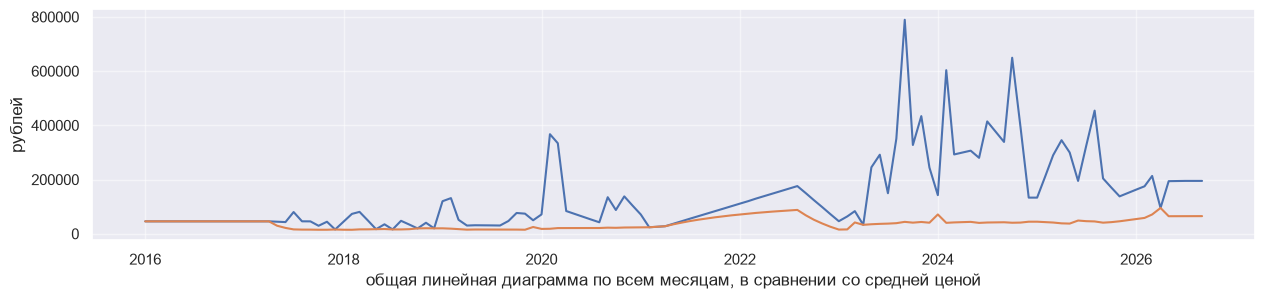

In [62]:
# общая линейная диаграмма по всем месяцам, чтобы видеть динамику, в сравнении со средней ценой
plt.figure(figsize = (15,3))
sns.lineplot(data=dataMonitor, x="date", y="sum")
sns.lineplot(data=dataMonitor, x="date", y="avg_price")
plt.xlabel("общая линейная диаграмма по всем месяцам, в сравнении со средней ценой")
plt.ylabel("рублей")
plt.show()

Видно, что основной рост закупок происходит после 2023 года, и закупки носят не постоянный характер и не зависят от средней цены, это говорит о том, что компания активно развивалась с 2023 по 2025 года

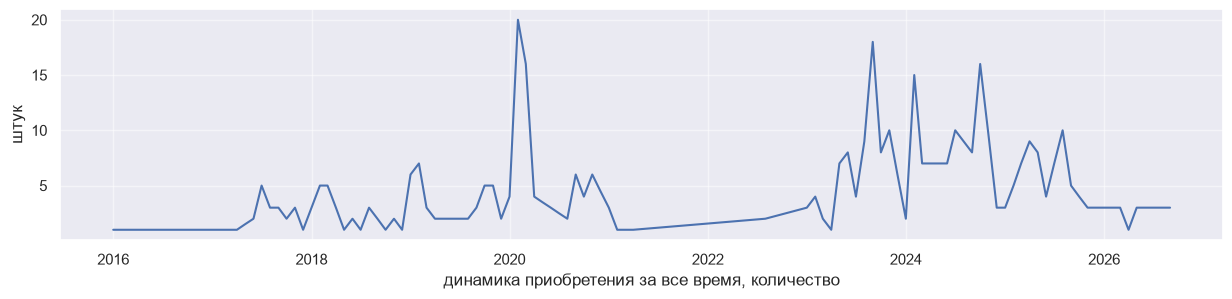

In [64]:
# динамика приобретения за все время, количество
plt.figure(figsize = (15,3))
sns.lineplot(data=dataMonitor, x="date", y="data_qty")
plt.xlabel("динамика приобретения за все время, количество")
plt.ylabel("штук")
plt.show()

Из даннного графика можно также выявить, что активно компания приобретала мониторы с 2023 по 2025 года, и был пик приоьретения в начале 2021 года, видимо было связано с каким то событием в компании. Начиная с 2026 года количество закупок мониторов выше, чем в 2016-2019 гг, это может быть связано с количеством сотрудников либо, количеством мониторов за одним рабочим местом

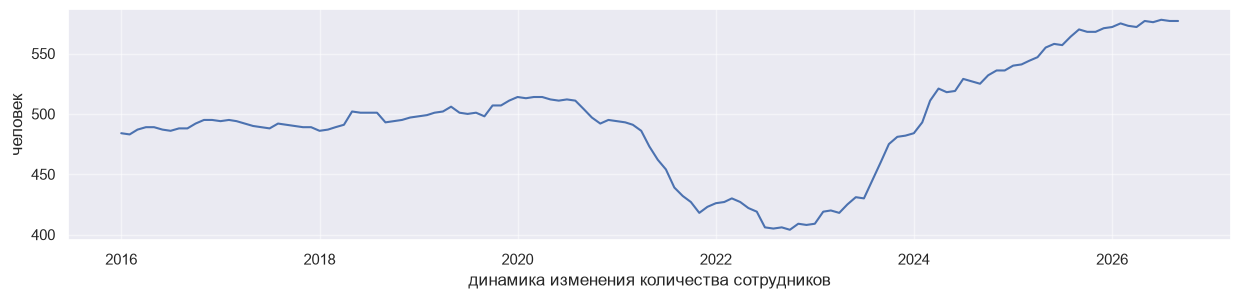

In [65]:
# динамика изменения количества сотрудников
plt.figure(figsize = (15,3))
sns.lineplot(data=dataMonitor, x="date", y="qty")
plt.xlabel("динамика изменения количества сотрудников")
plt.ylabel("человек")
plt.show()

Из графика видно, что количество сотрудников резко уменьшилось в кеонце 2021 года и начало восстанавливаться в конце 2023 года. Скорее всего это связано с обстановкой в стране. Также видно, что начиная с конца 2023 года произошел активный рост количества сотрудников

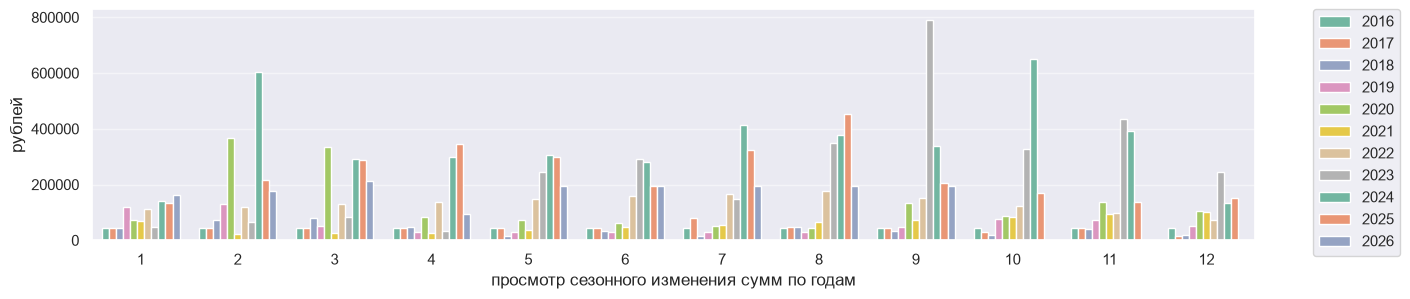

In [66]:
# просмотр сезонного изменения сумм по годам
plt.figure(figsize = (15,3))
sns.barplot(data=dataMonitor.sort_values("year"), x="month", y="sum", hue="year", palette="Set2")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.xlabel("просмотр сезонного изменения сумм по годам")
plt.ylabel("рублей")
plt.show()

Данный график показывает сезонную зависимость приобретения мониторов, из него можно сделать вывод, что имеются небольшие сезонные отклонения, их меньше в январе и декабре, и больше в июле-октябре, а также в феврале, но идет стабильный рост после 2024 года.

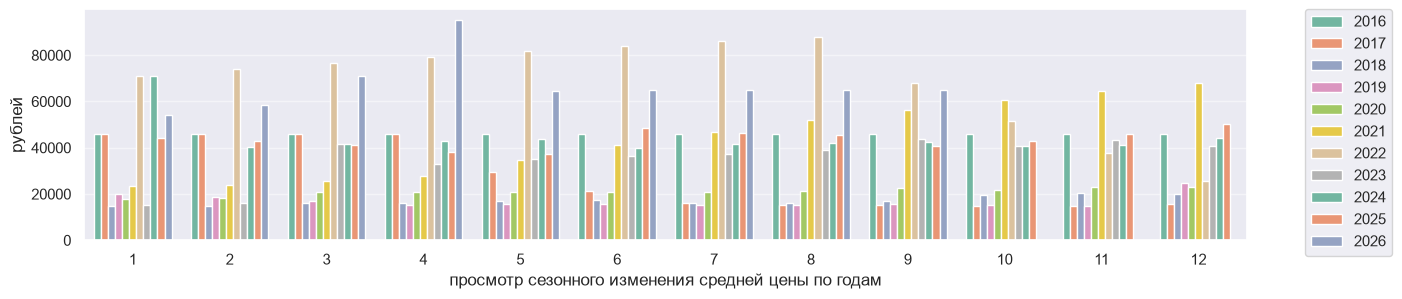

In [67]:
# просмотр сезонного изменения средней цены по годам
plt.figure(figsize = (15,3))
sns.barplot(data=dataMonitor, x="month", y="avg_price", hue="year", palette="Set2")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.xlabel("просмотр сезонного изменения средней цены по годам")
plt.ylabel("рублей")
plt.show()


Из графика видно, что средняя цена имеет небольшую сезонную зависимость, начиная с 2023 года, видимо это связано с курсом валюты.

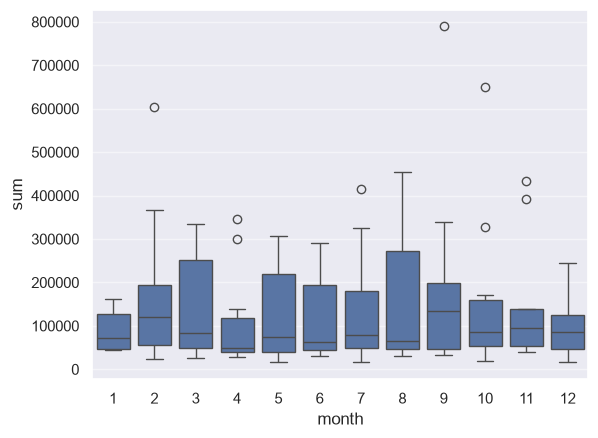

In [73]:
sns.boxplot(data =dataMonitor, x="month", y = "sum")
plt.show()

Из графика видно, что имеется сезонная зависимость по сумме покупок. В январе, апреле, ноябре хоть суммы и не большие, но более прогнозируемые, чем в другие месяца. В Феврале, марте, июле, августе, сентябре и декабре сложнее всего предсказать, т.к. идет большой разброс. Также имеются выбросы, скорее всего связанные с массовым приобритением (по ним можно судить, что в апреле, октябре и ноябре появлялась возможность приобрести мониторы в больших количествах, скорее всего это связано с финансовыми возможностями компаниями в тот момент)

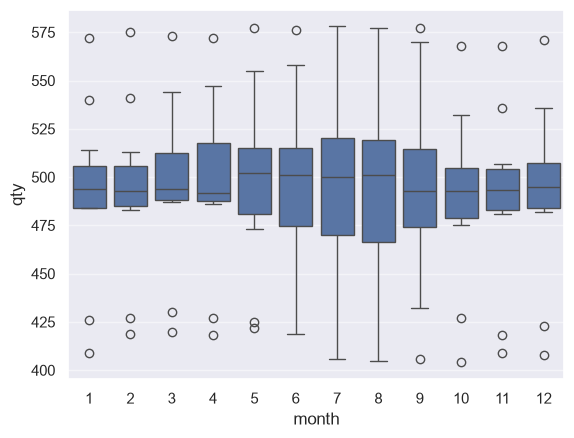

In [74]:
sns.boxplot(data =dataMonitor, x="month", y = "qty")
plt.show()

Данный график показывает стабильный средний состав сотрудников компании, но в январе, феврале и ноябре количество сотрудников более прогнозируемо, чем в летние месяцы. Бывают выбросы, скорее всего связанные с обстановкой в стране.

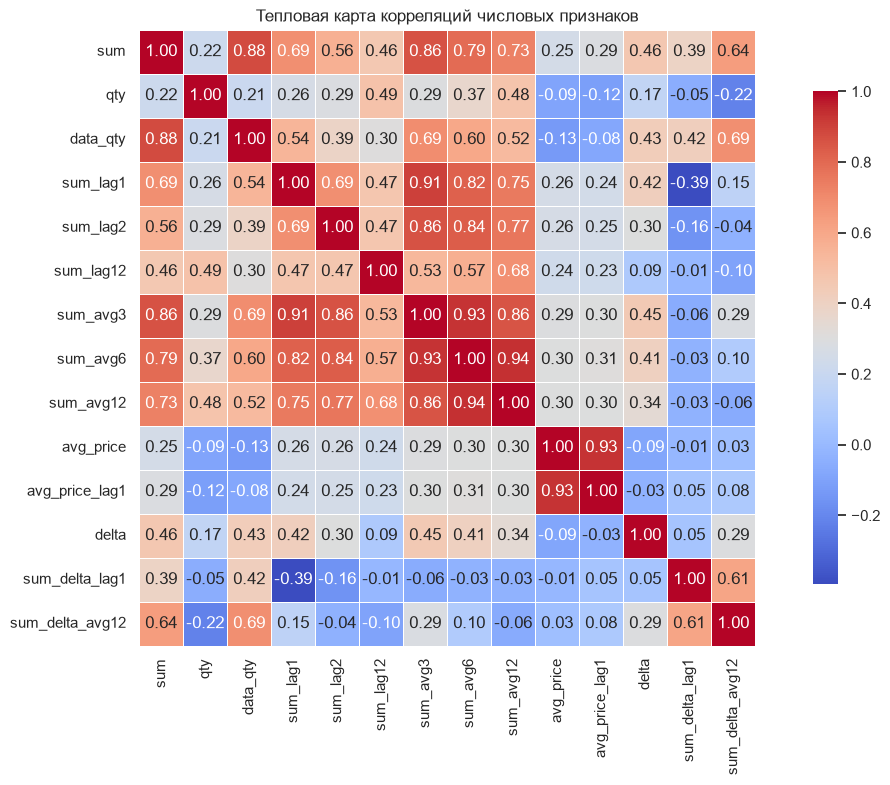

In [75]:
# Попытка выбобра числовых характеристик с помощью тепловой карты
numeric_cols = ['sum', 'qty', 'data_qty', 'sum_lag1', 'sum_lag2', 'sum_lag12',
                'sum_avg3', 'sum_avg6', 'sum_avg12', 'avg_price', 'avg_price_lag1',
                'delta', 'sum_delta_lag1', 'sum_delta_avg12']
df_numeric = dataMonitor[numeric_cols]
corr_matrix = df_numeric.corr()

plt.figure(figsize=(15, 8))  # размер графика
sns.heatmap(corr_matrix,
            annot=True,        # показывать значения коэффициентов в ячейках
            fmt='.2f',         # формат чисел (2 знака после запятой)
            cmap='coolwarm',   # цветовая схема: синий – отрицательная, красный – положительная
            square=True,       # квадратные ячейки
            linewidths=0.5,    # линии между ячейками
            cbar_kws={"shrink": 0.8})  # настройка цветовой шкалы
plt.title('Тепловая карта корреляций числовых признаков')
plt.show()


Из графика видно:
* qty (количество сотрудников) - имеет слабую корреляцию, но нужна для уточнения суммы
* data_qty (количество единиц товаров) - сильно коррелирует с sum, удалим его
* sum_lag1, sum_lag2, sum_lag12, sum_avg3, sum_avg6, sum_avg12 также имеют ссильную корреляцию, оставим только один sum_avg12 - это средняя за год, она будет показывать средний показатель
* avg_price и avg_price_lag1 такде имеют сильную корреляцию, оставим только один, avg_price - он поможет с уточнением суммы
* delta - имеет слабую корреляцию, поможет указать тренд
* um_delta_lag1 и sum_delta_avg12 - имеют сильную корреляцию, оставим только один sum_delta_avg12, он показывает тренд, это поможет для прогнозирования.

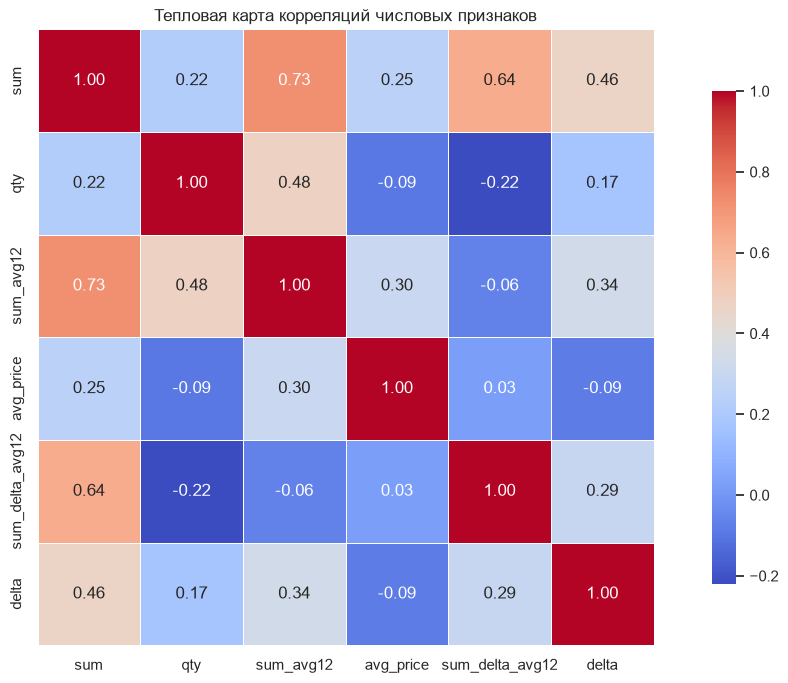

In [89]:
numeric_cols = ['sum', 'qty', 'sum_avg12', 'avg_price', 'sum_delta_avg12', 'delta']
df_numeric = dataMonitor[numeric_cols]
corr_matrix = df_numeric.corr()

plt.figure(figsize=(15, 8))  # размер графика
sns.heatmap(corr_matrix,
            annot=True,        # показывать значения коэффициентов в ячейках
            fmt='.2f',         # формат чисел (2 знака после запятой)
            cmap='coolwarm',   # цветовая схема: синий – отрицательная, красный – положительная
            square=True,       # квадратные ячейки
            linewidths=0.5,    # линии между ячейками
            cbar_kws={"shrink": 0.8})  # настройка цветовой шкалы
plt.title('Тепловая карта корреляций числовых признаков')
plt.show()


По графику видно, что выбранные 5 признаков имеют между собой слабую корреляцию, а значит с помощью их можно более точнее обучить модель для прогнозирования.

In [88]:
print("\nКорреляция по количеству сотрудников")
print(corr_matrix['qty'].sort_values(ascending=False))

print("\nКорреляция по средней цене за поледний год")
print(corr_matrix['sum_avg12'].sort_values(ascending=False))

print("\nКорреляция по средней цене")
print(corr_matrix['avg_price'].sort_values(ascending=False))

print("\nКорреляция по отклонению от средней суммы за год")
print(corr_matrix['sum_delta_avg12'].sort_values(ascending=False))

print("\nКорреляция по отклонению количества сотрудников")
print(corr_matrix['delta'].sort_values(ascending=False))


Корреляция по количеству сотрудников
qty                1.000000
sum_avg12          0.478113
delta              0.171598
avg_price         -0.091600
sum_delta_avg12   -0.219870
Name: qty, dtype: float64

Корреляция по средней цене за поледний год
sum_avg12          1.000000
qty                0.478113
delta              0.337360
avg_price          0.299872
sum_delta_avg12   -0.064903
Name: sum_avg12, dtype: float64

Корреляция по средней цене
avg_price          1.000000
sum_avg12          0.299872
sum_delta_avg12    0.025996
delta             -0.085386
qty               -0.091600
Name: avg_price, dtype: float64

Корреляция по отклонению от средней суммы за год
sum_delta_avg12    1.000000
delta              0.292720
avg_price          0.025996
sum_avg12         -0.064903
qty               -0.219870
Name: sum_delta_avg12, dtype: float64

Корреляция по отклонению количества сотрудников
delta              1.000000
sum_avg12          0.337360
sum_delta_avg12    0.292720
qty                

# Гиптотезы

## По признаку qty

Гипотеза: При сохранение количества сотрудников новые мониторы потребуются только для замены испорченных.

Описание: При сохранении количества сотрудников, компании не требуется подготавливать новые рабочие места (приобретать компьютеры, мониторы и т.д.) или при увольнении одного сотрудника его место занимает другой, при этом рабочее место сохраняется. Исключением может быть выход из строя монитора из-за состаривания или при возникновении нестандартной ситуации (пожар, уронили, облили водой, скачен напряжения и т.д.)

Практически: смысл этой гипотезы в том, что при соблюдении определенной численности сотрудников, ИТ отделу не потребуется приобретения мониторов, только в случае замены старых.


## По признаку sum_avg12

Гипотеза: сумма бюджета на месяц зависит от среднего уровня покупок за прошлый год.

Описание: Бюджетирование в компании зачастую происходит на основе исторических данных.

Практически: Поможет формировать бюджет на основе предыдущих данных за прошлый год.

## По признаку avg_price

Гипотеза: Средняя цена монитора положительно влияет на общую сумму бюджета.

Описание: При фиксированной средней цене, увеличение количества мониторов приведет к увеличению суммы. Сильное уменьшение средней цены скорее всего приведет к увеличению количества мониторов, но сохранит общую сумму.

Практически: Позволит планировать сумму бюджета более точно, при небольшом изменении средней цены. При резком снижении или увеличении поможет сбалансировать бюджет по количеству.

## По признаку sum_delta_avg12

Гипотеза: Если отклонение от среднего за год положительное, то сумма бюджета будет увеличение суммы бюджета.

Описание: Отклонение от среднего показывает текущий тренд - если компания увеличивает покупки, то скорее всего это будет продолжаться дальше.

Практически: Позволит планировать бюджет на более длительные сроки.

## По признаку delta

Гипотеза: Дельта количества сотрудников положительно влияет на сумму бюджета

Описание: Увеличение количества работников повышает потребность в новых мониторов.

Практически: Если будет известно, что планируется увеличить штат сотрудников, то можно будет заранее внести в бюджет соответствующие траты на формирование рабочего места сотрудника.